In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/devis_dataset.csv")
df.head()

,id,type_site,nb_pages,niveau_design,seo,ecommerce,paiement_en_ligne,animations,hebergement,nom_domaine,delai_jours,experience_client,prix_final
0,1,Landing Page,2,Standard,0,0,0,0,0,1,9,New Client,3900
1,2,Site Vitrine,5,Premium,1,0,0,1,1,0,33,New Client,7100
2,3,Site Vitrine,13,Standard,1,0,0,0,0,1,12,New Client,7200
3,4,Site Vitrine,5,Premium,1,0,0,0,1,0,30,New Client,5900
4,5,Landing Page,2,Basic,1,0,0,0,1,0,13,New Client,4200


In [3]:
print(df.columns.tolist())

['id', 'type_site', 'nb_pages', 'niveau_design', 'seo', 'ecommerce', 'paiement_en_ligne', 'animations', 'hebergement', 'nom_domaine', 'delai_jours', 'experience_client', 'prix_final']


In [4]:
df=df.drop(columns=["id"])

In [5]:
#Valeurs null
df.isnull().sum()

type_site            0
nb_pages             0
niveau_design        0
seo                  0
ecommerce            0
paiement_en_ligne    0
animations           0
hebergement          0
nom_domaine          0
delai_jours          0
experience_client    0
prix_final           0
dtype: int64

In [6]:
df.dtypes

type_site              str
nb_pages             int64
niveau_design          str
seo                  int64
ecommerce            int64
paiement_en_ligne    int64
animations           int64
hebergement          int64
nom_domaine          int64
delai_jours          int64
experience_client      str
prix_final           int64
dtype: object

In [7]:
#Encoding
from sklearn.preprocessing import LabelEncoder
le_type=LabelEncoder()
le_niveau=LabelEncoder()
le_experience=LabelEncoder()
df["type_site"]=le_type.fit_transform(df["type_site"])
df["niveau_design"]=le_niveau.fit_transform(df["niveau_design"])
df["experience_client"]=le_experience.fit_transform(df["experience_client"])


In [8]:
df.head()

,type_site,nb_pages,niveau_design,seo,ecommerce,paiement_en_ligne,animations,hebergement,nom_domaine,delai_jours,experience_client,prix_final
0,1,2,2,0,0,0,0,0,1,9,0,3900
1,2,5,1,1,0,0,1,1,0,33,0,7100
2,2,13,2,1,0,0,0,0,1,12,0,7200
3,2,5,1,1,0,0,0,1,0,30,0,5900
4,1,2,0,1,0,0,0,1,0,13,0,4200


In [9]:
#Choosing Target and Features
y=df["prix_final"]
X=df.drop(columns="prix_final")

In [10]:
#verify target and features
print(X.shape,y.shape)

(1000, 11) (1000,)


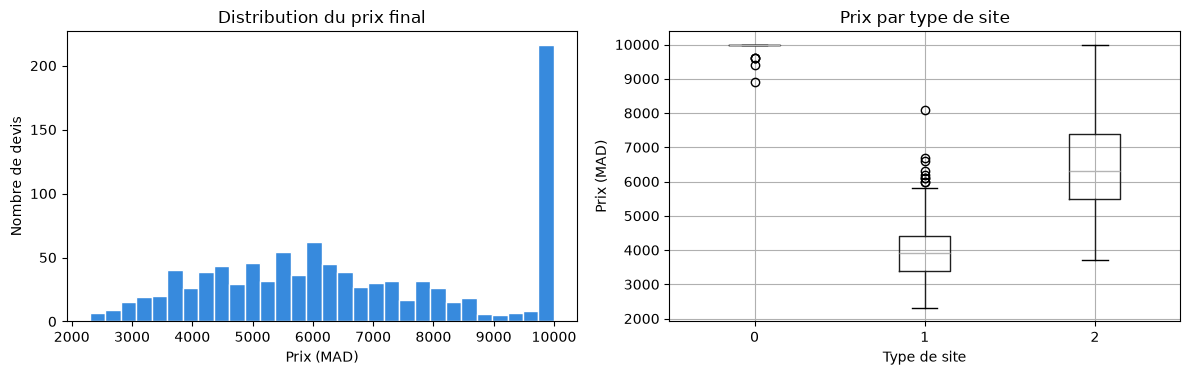

Graphique sauvegardé : eda_prix.png


In [11]:
#visualisation
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(y, bins=30, color="#378ADD", edgecolor="white")
axes[0].set_title("Distribution du prix final")
axes[0].set_xlabel("Prix (MAD)")
axes[0].set_ylabel("Nombre de devis")
 
# Boxplot par type de site
df.boxplot(column="prix_final", by="type_site", ax=axes[1])
axes[1].set_title("Prix par type de site")
axes[1].set_xlabel("Type de site")
axes[1].set_ylabel("Prix (MAD)")
plt.suptitle("")
 
plt.tight_layout()
plt.savefig("eda_prix.png", dpi=150)
plt.show()
print("Graphique sauvegardé : eda_prix.png")


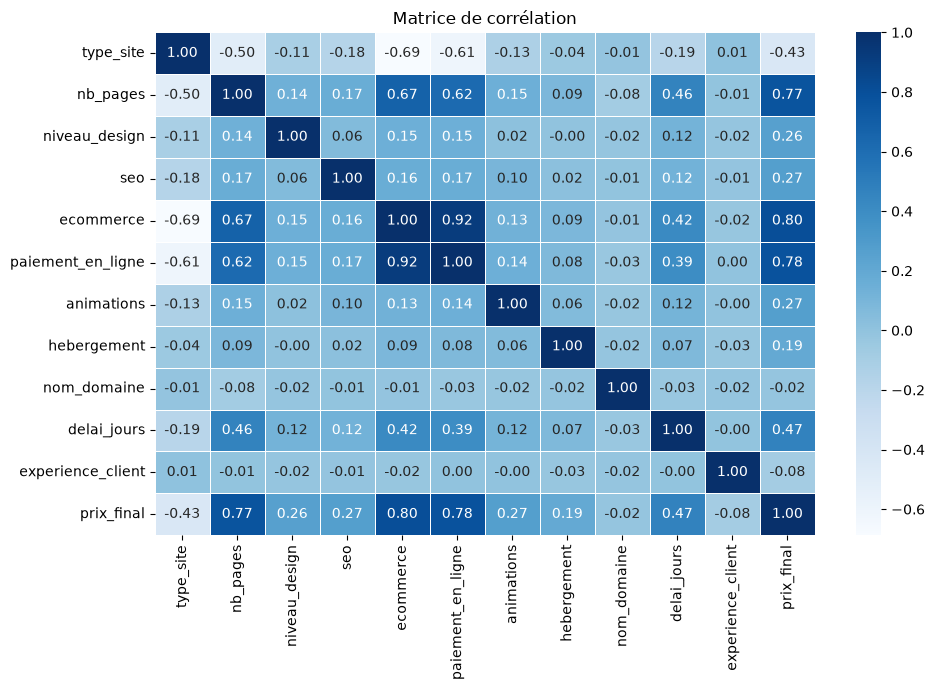

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150)
plt.show()

In [13]:
df_model = X.copy()
df_model["prix_final"] = y
df_model.to_csv("../data/devis_prepared.csv", index=False)
print("\nDataset préparé sauvegardé : devis_prepared.csv")
print("Prêt pour la Phase 3 — Modélisation !")


Dataset préparé sauvegardé : devis_prepared.csv
Prêt pour la Phase 3 — Modélisation !
